# Image preprocessing function

In [ ]:
import os
import cv2
import numpy as np

def deskew(img, max_angle_threshold=1.5):
    coords = np.column_stack(np.where(img < 255))
    if coords.shape[0] == 0:
        return img

    mean, eigenvectors = cv2.PCACompute(coords.astype(np.float32), mean=np.array([]))
    angle = np.arctan2(eigenvectors[0, 1], eigenvectors[0, 0]) * 180.0 / np.pi

    # ✅ Ignore angles that are too large (PCA mistake)
    if abs(angle) < max_angle_threshold:
        return img

    # ✅ If PCA thinks text is vertical, skip rotation
    if abs(angle) > 45:
        return img

    (h, w) = img.shape
    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    abs_cos = abs(M[0, 0])
    abs_sin = abs(M[0, 1])
    new_w = int(h * abs_sin + w * abs_cos)
    new_h = int(h * abs_cos + w * abs_sin)

    M[0, 2] += (new_w / 2) - center[0]
    M[1, 2] += (new_h / 2) - center[1]

    rotated = cv2.warpAffine(img, M, (new_w, new_h),
                              flags=cv2.INTER_CUBIC,
                              borderMode=cv2.BORDER_CONSTANT,
                              borderValue=255)

    # ✅ Force horizontal layout
    if rotated.shape[0] > rotated.shape[1]:
        rotated = cv2.rotate(rotated, cv2.ROTATE_90_CLOCKWISE)

    return rotated

def preprocess_image_for_ocr(
    image_path,
    save_path=None,
    binarize=True,
    use_bilateral=True
):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    # === Noise removal ===
    if use_bilateral:
        img = cv2.bilateralFilter(img, d=5, sigmaColor=75, sigmaSpace=75)
    else:
        img = cv2.GaussianBlur(img, (3, 3), 0)

    # === Padding before deskew ===
    img = cv2.copyMakeBorder(img, 20, 20, 20, 20, cv2.BORDER_CONSTANT, value=255)

    # === Deskew ===
    img = deskew(img)

    # === Binarization (no inversion) ===
    if binarize:
        img = cv2.adaptiveThreshold(
            img, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            31, 10
        )

    # Fix orientation if needed
    #if img.shape[1] > img.shape[0]:
        #img = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)

    # === Normalize & format ===
    img_norm = img.astype(np.float32) / 255.0
    img_norm = np.expand_dims(img_norm, axis=0)  # [1, H, W]

    # === Save output ===
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        cv2.imwrite(save_path, img)

    return img_norm

def preprocess_folder(
    input_folder,
    output_folder,
    binarize=True,
    use_bilateral=True,
    out_ext=".png",
    verbose=True
):
    os.makedirs(output_folder, exist_ok=True)

    for fname in os.listdir(input_folder):
        if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
            continue

        input_path = os.path.join(input_folder, fname)
        output_name = os.path.splitext(fname)[0] + out_ext
        output_path = os.path.join(output_folder, output_name)

        try:
            preprocess_image_for_ocr(
                image_path=input_path,
                save_path=output_path,
                binarize=binarize,
                use_bilateral=use_bilateral
            )
            if verbose:
                print(f"✅ Processed and saved: {output_name}")
        except Exception as e:
            print(f"❌ Failed on {fname}: {e}")

## Copying the images to one folder for faster access

In [24]:
import os
import shutil

def copy_images_to_single_folder(input_folder, output_folder, extensions=(".png", ".jpg", ".jpeg")):
    """
    Copies all images from subfolders in `input_folder` to `output_folder`.
    Keeps only files with specified extensions.
    Does not modify or process the images.
    """
    os.makedirs(output_folder, exist_ok=True)
    count = 0

    for root, _, files in os.walk(input_folder):
        for file in files:
            if file.lower().endswith(extensions):
                src_path = os.path.join(root, file)
                dst_path = os.path.join(output_folder, file)

                # Avoid overwrite by renaming if needed
                base, ext = os.path.splitext(file)
                counter = 1
                while os.path.exists(dst_path):
                    dst_path = os.path.join(output_folder, f"{base}_{counter}{ext}")
                    counter += 1

                shutil.copy2(src_path, dst_path)
                count += 1
                print(f"📁 Copied: {dst_path}")

    print(f"\n✅ Finished! {count} images copied to: {output_folder}")

In [24]:
copy_images_to_single_folder(
    input_folder="/Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/sentences",
    output_folder="/Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/sentences_all/"
)

📁 Copied: /Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/sentences_all/e04-127-s00-01.png
📁 Copied: /Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/sentences_all/e04-127-s00-00.png
📁 Copied: /Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/sentences_all/e04-127-s02-01.png
📁 Copied: /Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/sentences_all/e04-127-s02-00.png
📁 Copied: /Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/sentences_all/e04-127-s01-00.png
📁 Copied: /Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/sentences_all/e04-127-s01-01.png
📁 Copied: /Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/sentences_all/e04-127-s03-00.png
📁 Copied: /Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/sentences_all/e04-127-s03-01.png
📁 Copied: /Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/sentences_all/e04-127-s03-02.png
📁 Copied: /Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/sentences_all/e04-119-s01-02.png
📁 Copied: /Users/krishnanand/D

## Preprocessing the sentences images

In [27]:
preprocess_folder(
    input_folder="/Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/sentences_all/",
    output_folder="/Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/sentences_all/",
    binarize=True,
    use_bilateral=True
)

✅ Processed and saved: b04-121-s02-01.png
✅ Processed and saved: k07-125-s04-00.png
✅ Processed and saved: b01-127-s01-02.png
✅ Processed and saved: c06-116-s00-00.png
✅ Processed and saved: l04-118-s03-01.png
✅ Processed and saved: n02-037-s01-04.png
✅ Processed and saved: g06-037n-s01-01.png
✅ Processed and saved: b01-136-s01-00.png
✅ Processed and saved: g06-037b-s02-03.png
✅ Processed and saved: n02-098-s01-01.png
✅ Processed and saved: b02-035-s00-03.png
✅ Processed and saved: k07-122-s00-03.png
✅ Processed and saved: p01-147-s04-00.png
✅ Processed and saved: l01-119-s04-01.png
✅ Processed and saved: n03-106-s04-00.png
✅ Processed and saved: g06-018p-s02-03.png
✅ Processed and saved: p02-121-s03-02.png
✅ Processed and saved: j04-080-s00-02.png
✅ Processed and saved: e02-100-s01-00.png
✅ Processed and saved: n06-074-s01-00.png
✅ Processed and saved: a05-080-s00-05.png
✅ Processed and saved: g06-011e-s05-00.png
✅ Processed and saved: c04-122-s01-00.png
✅ Processed and saved: b02-097

## Reading the Data from Sentence

### creating metadata from sentence

In [15]:
import os
import csv
import concurrent.futures

def scan_images_multithreaded(image_base_folder):
    """
    Scans base and subfolders, returns {form_id: full_image_path}
    Supports .png, .jpg, .jpeg (case insensitive)
    """
    all_images = {}

    def scan_folder(folder):
        sub_images = {}
        for root, _, files in os.walk(folder):
            for file in files:
                if file.lower().endswith(('.jpeg', '.jpg', '.png')):
                    form_id = os.path.splitext(file)[0].lower()
                    sub_images[form_id] = os.path.join(root, file)
        return sub_images

    # ✅ Scan base folder + any subdirectories
    scan_targets = [image_base_folder] + [
        os.path.join(image_base_folder, sub)
        for sub in os.listdir(image_base_folder)
        if os.path.isdir(os.path.join(image_base_folder, sub))
    ]

    with concurrent.futures.ThreadPoolExecutor() as executor:
        futures = [executor.submit(scan_folder, folder) for folder in scan_targets]
        for future in concurrent.futures.as_completed(futures):
            all_images.update(future.result())

    return all_images

def create_metadata_from_sentences(sentence_txt_path, image_base_folder, output_csv_path):
    """
    Parses sentences.txt and builds a metadata CSV with:
    [form_id, image_path, printed_transcription]
    Uses multithreaded image scanning.
    """
    print("\U0001F50D Scanning image folders...")
    image_paths = scan_images_multithreaded(image_base_folder)
    print(f"✅ Found {len(image_paths)} image files")

    dataset = []

    with open(sentence_txt_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue

            parts = line.split()
            if len(parts) < 9:
                continue  # malformed line

            form_id = parts[0].lower()  # normalize
            text_tokens = parts[8:]
            clean_tokens = [t for t in text_tokens if not t.isdigit()]
            text = " ".join(clean_tokens).replace("|", " ")

            if form_id in image_paths:
                dataset.append([form_id, image_paths[form_id], text])
            else:
                print(f"⚠️ Image not found for: {form_id}")

    # Save to CSV
    with open(output_csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["form_id", "image_path", "transcription"])
        writer.writerows(dataset)

    print(f"✅ Sentence metadata saved to: {output_csv_path}")


In [26]:
create_metadata_from_sentences(
    sentence_txt_path="/Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/ascii/sentences.txt",
    image_base_folder="/Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/sentences_all/",
    output_csv_path="Sentence_Metadata.csv"
)

🔍 Scanning image folders...
✅ Found 16752 image files
✅ Sentence metadata saved to: Sentence_Metadata.csv


## Creating a Dataframe so it could be used to merge

In [20]:
import pandas as pd
sentence_df = pd.read_csv("Sentence_Metadata.csv")

In [21]:
sentence_df 

,form_id,image_path,transcription
0,a01-000u-s00-00,/Users/krishnanand/Documents/Git/Data/IMHANDWR...,A MOVE to stop Mr. Gaitskell from
1,a01-000u-s00-01,/Users/krishnanand/Documents/Git/Data/IMHANDWR...,nominating any more Labour life Peers
2,a01-000u-s00-02,/Users/krishnanand/Documents/Git/Data/IMHANDWR...,is to be made at a meeting of Labour
3,a01-000u-s00-03,/Users/krishnanand/Documents/Git/Data/IMHANDWR...,M Ps tomorrow .
4,a01-000u-s01-00,/Users/krishnanand/Documents/Git/Data/IMHANDWR...,Mr. Michael Foot has
...,...,...,...
16747,r06-143-s01-01,/Users/krishnanand/Documents/Git/Data/IMHANDWR...,"in front of her , but she said :"
16748,r06-143-s02-00,/Users/krishnanand/Documents/Git/Data/IMHANDWR...,' Philip 's awfully lucky .
16749,r06-143-s03-00,/Users/krishnanand/Documents/Git/Data/IMHANDWR...,I wish I went to that school .
16750,r06-143-s04-00,/Users/krishnanand/Documents/Git/Data/IMHANDWR...,Did you notice


## Reading images with the ground truth 

### Pre- processing the ImHANDWRTITNG dataset 1 : metadata creation

In [22]:
import os
import csv
import concurrent.futures
from collections import defaultdict

# Paths
base_folder = "/Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/"  # This should contain formsA-D, formsE-H, ...
lines_txt_path = "/Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/ascii/lines.txt"  # Adjust if needed
output_csv = "Handwriting_1_matadata.csv"

# Step 1: Load and parse lines.txt
form_lines = defaultdict(list)

with open(lines_txt_path, "r", encoding="utf-8") as f:
    for line in f:
        if line.startswith("#") or not line.strip():
            continue
        parts = line.strip().split()
        line_id = parts[0]
        form_id = "-".join(line_id.split("-")[:2])
        text = " ".join(parts[8:]).replace("|", " ")
        form_lines[form_id].append(text)

# Step 2: Scan all folders for image paths
def scan_for_images(folder):
    img_paths = {}
    for root, _, files in os.walk(folder):
        for file in files:
            if file.endswith((".png", ".jpeg", ".jpg")):
                form_id = os.path.splitext(file)[0]
                img_paths[form_id] = os.path.join(root, file)
    return img_paths

# Use multithreading for scanning
form_image_paths = {}

with concurrent.futures.ThreadPoolExecutor() as executor:
    futures = [executor.submit(scan_for_images, os.path.join(base_folder, subfolder))
               for subfolder in os.listdir(base_folder)
               if subfolder.startswith("forms")]
    for future in concurrent.futures.as_completed(futures):
        form_image_paths.update(future.result())

# Step 3: Build dataset
dataset = []

for form_id, lines in form_lines.items():
    if form_id in form_image_paths:
        image_path = form_image_paths[form_id]
        text = " ".join(lines)
        dataset.append([form_id, image_path, text])

# Step 4: Write to CSV
with open(output_csv, "w", newline="", encoding="utf-8") as out_file:
    writer = csv.writer(out_file)
    writer.writerow(["form_id", "image_path", "transcription"])
    writer.writerows(dataset)

print(f"Dataset saved to: {output_csv}")

Dataset saved to: Handwriting_1_matadata.csv


## Preprocessing image: the full handwritten

In [25]:
preprocess_folder(
    input_folder="/Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/formsA-D",
    output_folder="/Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/formsA-D",
    binarize=True,
    use_bilateral=True
)

✅ Processed and saved: a04-006.png
✅ Processed and saved: c03-087e.png
✅ Processed and saved: a02-057.png
✅ Processed and saved: d07-082.png
✅ Processed and saved: d07-096.png
✅ Processed and saved: a05-017.png
✅ Processed and saved: b04-026.png
✅ Processed and saved: d06-050.png
✅ Processed and saved: c06-020.png
✅ Processed and saved: d05-030.png
✅ Processed and saved: c02-000.png
✅ Processed and saved: d04-021.png
✅ Processed and saved: b06-042.png
✅ Processed and saved: b06-056.png
✅ Processed and saved: d04-008.png
✅ Processed and saved: c04-044.png
✅ Processed and saved: c04-050.png
✅ Processed and saved: d05-025.png
✅ Processed and saved: b02-102.png
✅ Processed and saved: a01-049x.png
✅ Processed and saved: b04-147.png
✅ Processed and saved: d06-086.png
✅ Processed and saved: a03-047.png
✅ Processed and saved: a02-042.png
✅ Processed and saved: b03-098.png
✅ Processed and saved: c03-087d.png
✅ Processed and saved: c03-087f.png
✅ Processed and saved: a04-039.png
✅ Processed and 

In [75]:
preprocess_folder(
    input_folder="/Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/formsE-H",
    output_folder="/Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/formsE-H",
    binarize=True,
    use_bilateral=True
)

In [76]:
preprocess_folder(
    input_folder="/Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/formsI-Z",
    output_folder="/Users/krishnanand/Documents/Git/Data/IMHANDWRITING_1/formsI-Z",
    binarize=True,
    use_bilateral=True
)

## Creating Dataframe

In [10]:
import pandas as pd
df = pd.read_csv("Handwriting_1_matadata.csv")

In [11]:
df

## Merging two dataframes

In [12]:
df = pd.concat([df, sentence_df], axis=0)

In [13]:
df

In [1]:
import pandas as pd
df = pd.read_csv("Handwriting_1_matadata.csv")
df.to_csv('Handwriting_1_matadata.csv', index=False) 

In [4]:
df = pd.read_csv("Sentence_Metadata.csv")

### Tokenization 

In [5]:
import pandas as pd

class OCRTokenizer:
    def __init__(self, text_column='transcription'):
        text_data = "".join(df[text_column].astype(str).tolist())

        self.text_column = text_column
        self.vocab = sorted(set(text_data))
        self.char2idx = {char: idx + 1 for idx, char in enumerate(self.vocab)}  # Start from 1
        self.char2idx['[BLANK]'] = 0  # CTC blank token

        self.idx2char = {idx: char for char, idx in self.char2idx.items()}

    def encode(self, text):
        return [self.char2idx[char] for char in text if char in self.char2idx]

    def decode(self, indices):
        return "".join([self.idx2char.get(idx, '') for idx in indices if idx > 0])

    def __len__(self):
        return len(self.char2idx)


def tokenize_dataset_csv(csv_path, tokenizer, text_column="transcription", save_as=None):
    """
    Tokenizes the entire dataset using the tokenizer.
    Adds 'encoded_label' column and optionally saves to disk.
    """
    df = pd.read_csv(csv_path)
    
    if text_column not in df.columns:
        raise ValueError(f"❌ Column '{text_column}' not found in CSV.")

    df['encoded_label'] = df[text_column].astype(str).apply(tokenizer.encode)

    if save_as:
        df.to_csv(save_as, index=False)
        print(f"✅ Tokenized CSV saved to: {save_as}")

    return df

In [6]:
tokenizer = OCRTokenizer(text_column="transcription")

tokenized_df = tokenize_dataset_csv(
    "Sentence_Metadata.csv",
    tokenizer,
    text_column="transcription",
    save_as="Handwriting_1_tokenized.csv"
)

✅ Tokenized CSV saved to: Handwriting_1_tokenized.csv


### Train and validation set splits

In [7]:
import pandas as pd
import os
import random

def split_dataset_csv(
    csv_path,
    train_csv_path,
    test_csv_path,
    split_ratio=0.8,
    shuffle=True,
    seed=42
):
    """
    Split a labeled dataset CSV into train/test.
    """
    df = pd.read_csv(csv_path)

    if shuffle:
        df = df.sample(frac=1, random_state=seed).reset_index(drop=True)

    split_index = int(len(df) * split_ratio)
    train_df = df.iloc[:split_index]
    test_df = df.iloc[split_index:]

    train_df.to_csv(train_csv_path, index=False)
    test_df.to_csv(test_csv_path, index=False)

    print(f"Train: {len(train_df)} samples")
    print(f"Test:  {len(test_df)} samples")

In [8]:
split_dataset_csv(
    csv_path="/Users/krishnanand/Documents/Git/VisionSpeak/Handwriting_1_tokenized.csv",
    train_csv_path="/Users/krishnanand/Documents/Git/VisionSpeak/train.csv",
    test_csv_path="/Users/krishnanand/Documents/Git/VisionSpeak/test.csv",
    split_ratio=0.9
)

Train: 15076 samples
Test:  1676 samples


### Creating Dataloder

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
import pandas as pd
import ast

class OCRDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_path"]
        label_encoded = ast.literal_eval(row["encoded_label"])

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Image not found: {img_path}")

        # Images are already resized/padded — no resize here
        img = img.astype(np.float32) / 255.0
        img = np.expand_dims(img, axis=0)  # [1, H, W]

        return {
            "image": torch.tensor(img, dtype=torch.float32),
            "label": torch.tensor(label_encoded, dtype=torch.long),
            "label_length": len(label_encoded),
            "img_path": img_path
        }

def ctc_collate_fn(batch):
    images = [item["image"] for item in batch]
    labels = [item["label"] for item in batch]

    image_batch = torch.stack(images)
    label_lengths = torch.tensor([len(label) for label in labels], dtype=torch.long)
    padded_labels = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value=0)

    return {
        "images": image_batch,
        "labels": padded_labels,
        "label_lengths": label_lengths,
    }

# === Usage ===
train_csv_path = "/Users/krishnanand/Documents/Git/VisionSpeak/train.csv"
test_csv_path  = "/Users/krishnanand/Documents/Git/VisionSpeak/test.csv"

train_dataset = OCRDataset(train_csv_path)
test_dataset  = OCRDataset(test_csv_path)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=ctc_collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=2, shuffle=False, collate_fn=ctc_collate_fn)

print("✅ DataLoaders ready!")
print("🔢 Train size:", len(train_dataset))
print("🔢 Test size:", len(test_dataset))

✅ DataLoaders ready!
🔢 Train size: 15076
🔢 Test size: 1676


## Modelling

In [10]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"✅ Using device: {device}")

✅ Using device: mps


#### Baseline 1 

In [11]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import torch
from PIL import Image

# === TrOCR Dataset ===
class TrOCRDataset(Dataset):
    def __init__(self, csv_path, processor):
        self.df = pd.read_csv(csv_path)
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert("RGB")
        pixel_values = self.processor(images=img, return_tensors="pt").pixel_values.squeeze(0)
        
        return {
            'pixel_values': pixel_values,
            'text': row['transcription']  # fixed here
        }

# === Collate Function ===
def trocr_collate_fn(batch, processor):
    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    texts = [item['text'] for item in batch]
    labels = processor.tokenizer(texts, padding="longest", return_tensors="pt").input_ids
    labels[labels == processor.tokenizer.pad_token_id] = -100  # For CrossEntropyLoss
    return {'pixel_values': pixel_values, 'labels': labels}

# === Load Pretrained Model and Processor ===
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")
model.config.decoder_start_token_id = processor.tokenizer.bos_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)

# === DataLoader ===
train_dataset = TrOCRDataset("/Users/krishnanand/Documents/Git/VisionSpeak/train.csv", processor)
test_dataset = TrOCRDataset("/Users/krishnanand/Documents/Git/VisionSpeak/test.csv", processor)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,
                          collate_fn=lambda x: trocr_collate_fn(x, processor))
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False,
                         collate_fn=lambda x: trocr_collate_fn(x, processor))

# === Training Loop ===
from torch import nn
from transformers import AdamW

optimizer = AdamW(model.parameters(), lr=5e-5)
loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

for epoch in range(3):
    model.train()
    total_loss = 0
    for batch in train_loader:
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in test_loader:
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss
            val_loss += loss.item()

    print(f" Epoch {epoch+1} —  Train Loss: {total_loss / len(train_loader):.4f} |  Val Loss: {val_loss / len(test_loader):.4f}")

print("TrOCR Baseline training complete!")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "torch_dtype": "float32",
  "transformers_version": "4.49.0"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> i

KeyboardInterrupt: 

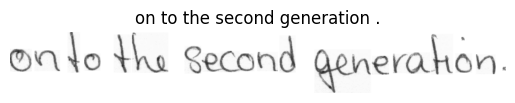

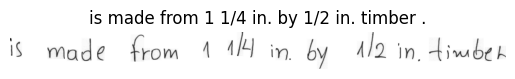

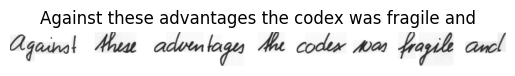

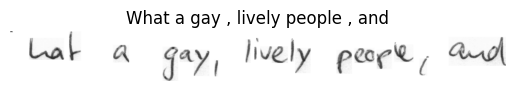

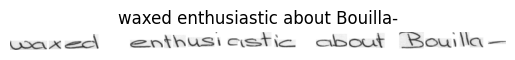

In [10]:
from PIL import Image
import matplotlib.pyplot as plt
import random
import pandas as pd

df = pd.read_csv("Sentence_Metadata.csv")
sample = df.sample(5)

for _, row in sample.iterrows():
    img = Image.open(row['image_path']).convert("RGB")
    plt.imshow(img)
    plt.title(row['transcription'])
    plt.axis("off")
    plt.show()

## Language Detection

In [ ]:
import fasttext
import torch

# Detect the best available device
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Ensure correct path to model file
model_path = "/Users/krishnanand/Documents/Git/Dependencies/lid.176.bin"  # Update this path if necessary
model = fasttext.load_model(model_path)

def detect_language(text):
    """Detect language of given text using FastText."""
    predictions = model.predict(text)
    lang_code = predictions[0][0].replace('__label__', '')
    return lang_code

text = "Bonjour, comment allez-vous?"
detected_lang = detect_language(text)
print(f"Detected Language: {detected_lang}")

## Summarization  

In [ ]:
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else (0 if torch.backends.mps.is_available() else -1)

# Load summarization pipeline (T5-Base)
summarizer = pipeline("summarization", model="t5-base", device=device)

# Example input text
text = """
Artificial intelligence (AI) is the simulation of human intelligence processes by machines, especially computer systems. 
These processes include learning, reasoning, and self-correction. AI is one of the most exciting and disruptive technologies 
of our time, influencing everything from healthcare to transportation.
"""

# Generate summary
summary = summarizer(text, max_length=100, min_length=30, do_sample=False)
summary_text = summary[0]['summary_text']
print("Summary in English:", summary_text)

# Load translation pipeline with a better model
translator = pipeline("translation", model="Helsinki-NLP/opus-mt-en-es", device=device)

# Translate the summary
translated_summary = translator(summary_text)
print("Translated Summary in Spanish:", translated_summary[0]['translation_text'])

## Translator

In [ ]:
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else (0 if torch.backends.mps.is_available() else -1)

# Load the NLLB model for French to Hindi translation
translator = pipeline("translation", model="facebook/nllb-200-distilled-600M", device=device)

# Example French text
text = "Bonjour, comment allez-vous aujourd'hui?"

# Translate the text from French to English
translated_text = translator(text, src_lang="fra_Latn", tgt_lang="eng_Latn")
english_translation = translated_text[0]['translation_text']
print("Translated to English:", english_translation)

# Now, translate from English to Hindi
translated_to_hindi = translator(english_translation, src_lang="eng_Latn", tgt_lang="hin_Deva")
print("Translated to Hindi:", translated_to_hindi[0]['translation_text'])

## TTS

In [ ]:
from TTS.api import TTS
import torch

# Detect best available device (CUDA for NVIDIA, MPS for Apple Silicon, CPU as fallback)
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Load a single-language English TTS model and move it to the selected device
tts = TTS("tts_models/en/ljspeech/tacotron2-DDC").to(device)

# Text to convert
text = ("The error 'Model is not multi-lingual but language is provided' means that "
        "the model does not support multiple languages. This model can only generate speech in English, "
        "so specifying language (French) is invalid.")

# Convert text to speech and save as an audio file
tts.tts_to_file(text=text, file_path="/Users/krishnanand/Documents/Git/Tests/test123.wav")

print("Speech synthesis complete! Output saved as 'test123.wav'.")

In [ ]:
pip install colabcode

In [ ]:
%pip install colabcode